In [1]:
# ==========================================
# KOMPONEN 1: Pemilihan Kasus & Dataset
# ==========================================
"""
KASUS PENGGUNAAN: Eksplorasi Cluster & Visualisasi Karakteristik Kimia Anggur (Wine Dataset)
- Masalah: Dataset ini memiliki 13 dimensi (fitur) hasil analisis laboratorium. Manusia tidak dapat
  melihat pola pengelompokan alami dalam ruang 13 dimensi.
- Kebutuhan Reduksi Dimensi: Mereduksi fitur menjadi 2D guna mengetahui apakah 3 kultivar anggur
  (Class 0, 1, 2) dapat dipisahkan secara visual berdasarkan kandungan kimianya.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
# Load dan standarisasi data
wine = load_wine()
X = wine.data
y = wine.target
target_names = wine.feature_names # Menyimpan nama fitur

In [4]:
# Standardisasi fitur (Penting agar PCA tidak bias terhadap fitur dengan skala besar)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset berhasil dimuat: {X.shape[0]} sampel dengan {X.shape[1]} fitur kimia.")

Dataset berhasil dimuat: 178 sampel dengan 13 fitur kimia.


In [5]:
# ==========================================
# KOMPONEN 2: Implementasi PCA
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Menghitung persentase informasi yang dipertahankan
var_ratio = pca.explained_variance_ratio_
print("\n--- HASIL EVALUASI PCA ---")
print(f"Principal Component 1 (PC1) menjelaskan {var_ratio[0]:.2%} varians.")
print(f"Principal Component 2 (PC2) menjelaskan {var_ratio[1]:.2%} varians.")
print(f"Total informasi global yang dipertahankan dalam 2D: {sum(var_ratio):.2%}")


--- HASIL EVALUASI PCA ---
Principal Component 1 (PC1) menjelaskan 36.20% varians.
Principal Component 2 (PC2) menjelaskan 19.21% varians.
Total informasi global yang dipertahankan dalam 2D: 55.41%


In [6]:
# ==========================================
# KOMPONEN 3: Implementasi t-SNE
# ==========================================
# Parameter perplexity=30 umum digunakan untuk menjaga keseimbangan aspek lokal/global data
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("\nt-SNE berhasil diselesaikan setelah proses iterasi.")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



t-SNE berhasil diselesaikan setelah proses iterasi.


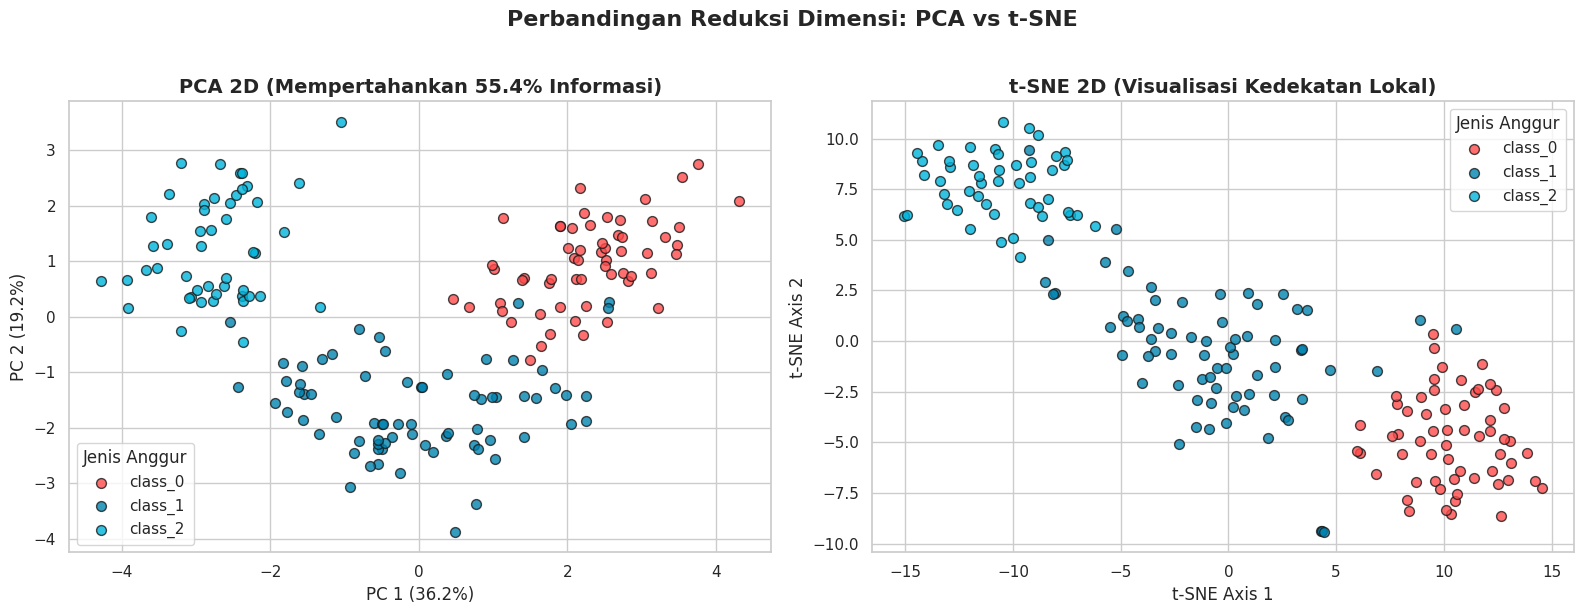

In [7]:
# ==========================================
# VISUALISASI UTAMA (Untuk Komponen PCA & t-SNE)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#FF4B4B', '#0083B0', '#00B4DB']

# Plot 1: Visualisasi PCA
for target, color, name in zip(range(3), colors, wine.target_names):
    axes[0].scatter(X_pca[y == target, 0], X_pca[y == target, 1],
                    label=name, color=color, alpha=0.8, edgecolors='k', s=50)
axes[0].set_title(f'PCA 2D (Mempertahankan {sum(var_ratio):.1%} Informasi)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC 1 ({var_ratio[0]:.1%})')
axes[0].set_ylabel(f'PC 2 ({var_ratio[1]:.1%})')
axes[0].legend(title="Jenis Anggur")

# Plot 2: Visualisasi t-SNE
for target, color, name in zip(range(3), colors, wine.target_names):
    axes[1].scatter(X_tsne[y == target, 0], X_tsne[y == target, 1],
                    label=name, color=color, alpha=0.8, edgecolors='k', s=50)
axes[1].set_title('t-SNE 2D (Visualisasi Kedekatan Lokal)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Axis 1')
axes[1].set_ylabel('t-SNE Axis 2')
axes[1].legend(title="Jenis Anggur")

plt.suptitle('Perbandingan Reduksi Dimensi: PCA vs t-SNE', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()